# 05 — LSTM Time-Series Forecasting
**Gurugram Air Quality Study (2020–2024)**

Trains a stacked LSTM network on the daily PM₂.₅ time series to forecast next-day values.

**Architecture:** `LSTM(64) → Dropout(0.2) → LSTM(32) → Dense(1)`  
**Lookback window:** 30 days → predict day 31  
**Output:** metrics appended to `outputs/regression_comparison.csv`, training curve, forecast plot.

**Requires:** Run `01_data_preprocessing.ipynb` first.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300, "font.size": 11})

BASE = os.getcwd()
OUT  = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(os.path.join(OUT, "merged_clean.csv"), parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(f"Loaded: {df.shape}")

Loaded: (1768, 32)


## 1. Prepare Time Series

In [2]:
PM_COL = "PM2.5 (µg/m³)"

# Use univariate PM2.5 series; fill any remaining gaps with forward fill
ts = df[["date", PM_COL]].dropna(subset=[PM_COL]).copy()
ts = ts.set_index("date").resample("D").mean()  # ensure daily frequency
ts = ts.ffill(limit=7).dropna()  # fill up to 7-day gaps

values = ts[PM_COL].values.reshape(-1, 1)
print(f"Time series length: {len(values)} days")
print(f"Date range: {ts.index[0].date()} → {ts.index[-1].date()}")

Time series length: 1801 days
Date range: 2020-01-01 → 2024-12-31


## 2. Scale & Create Sliding Windows

In [3]:
LOOKBACK = 30
TRAIN_SPLIT = 0.80

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

def make_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = make_sequences(scaled, LOOKBACK)
X_all = X_all.reshape(X_all.shape[0], X_all.shape[1], 1)  # (samples, timesteps, features)

split = int(len(X_all) * TRAIN_SPLIT)
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]
dates_test = ts.index[LOOKBACK + split:]

print(f"Train sequences: {len(X_train)} | Test sequences: {len(X_test)}")

Train sequences: 1416 | Test sequences: 355


## 3. Build LSTM Model

In [4]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
], name="LSTM_PM25")

model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "LSTM_PM25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train

In [5]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6),
]

t0 = time.time()
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1,
)
lstm_train_time = time.time() - t0
print(f"\nTraining time: {lstm_train_time:.1f}s")

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0200 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0166 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0166 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0169 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0165 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0162 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0159 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0156 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0156 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 10/1

## 5. Training Loss Curve

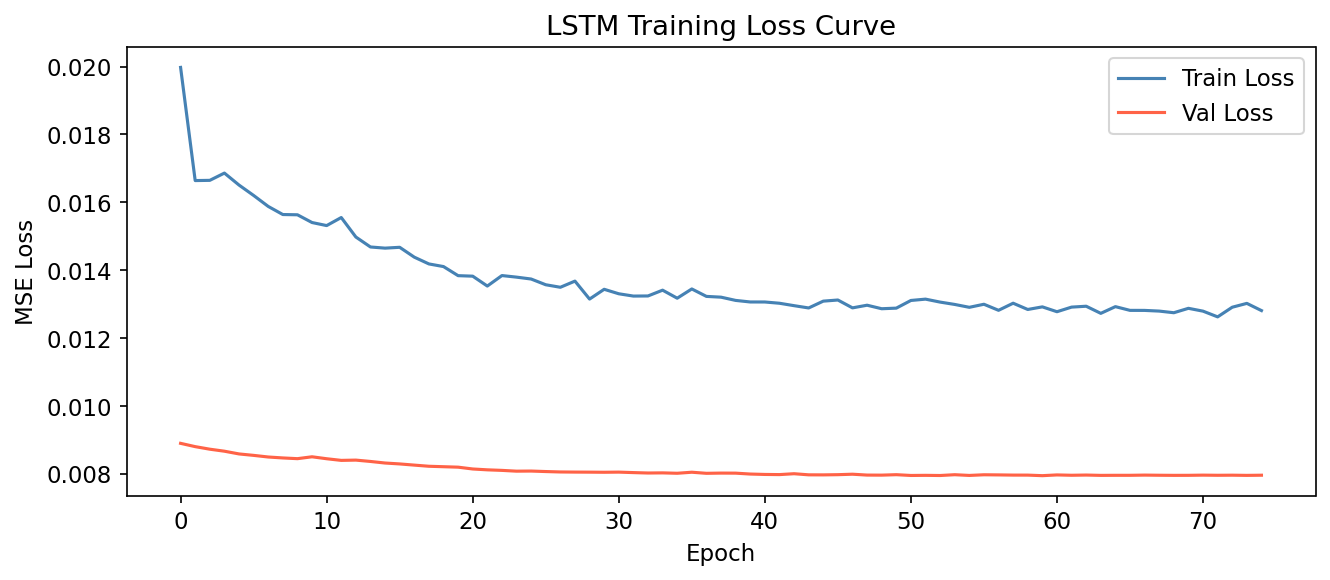

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history.history["loss"],     label="Train Loss", color="steelblue", lw=1.5)
ax.plot(history.history["val_loss"], label="Val Loss",   color="tomato",    lw=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("LSTM Training Loss Curve")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(OUT, "lstm_loss_curve.png"))
plt.show()

## 6. Evaluate on Test Set

In [7]:
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print(f"LSTM Results:")
print(f"  MAE  = {mae:.2f} µg/m³")
print(f"  RMSE = {rmse:.2f} µg/m³")
print(f"  R²   = {r2:.3f}")
print(f"  Training time = {lstm_train_time:.1f}s")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
LSTM Results:
  MAE  = 27.90 µg/m³
  RMSE = 38.88 µg/m³
  R²   = 0.403
  Training time = 48.2s


## 7. Append LSTM to Regression Comparison Table

In [8]:
reg_path = os.path.join(OUT, "regression_comparison.csv")

lstm_row = pd.DataFrame([{
    "Model": "LSTM",
    "MAE":   round(mae, 2),
    "RMSE":  round(rmse, 2),
    "R²":    round(r2, 3),
    "Training Time (s)": round(lstm_train_time, 1),
}])

if os.path.exists(reg_path):
    reg_df = pd.read_csv(reg_path)
    # Remove any previous LSTM entry
    reg_df = reg_df[reg_df["Model"] != "LSTM"]
    reg_df = pd.concat([reg_df, lstm_row], ignore_index=True)
else:
    reg_df = lstm_row

reg_df = reg_df.sort_values("RMSE")
reg_df.to_csv(reg_path, index=False)

print("\n══════════════════════════════════════════════════════════")
print("    FULL REGRESSION COMPARISON TABLE (with LSTM)")
print("══════════════════════════════════════════════════════════")
print(reg_df.to_string(index=False))
print("══════════════════════════════════════════════════════════")
reg_df


══════════════════════════════════════════════════════════
    FULL REGRESSION COMPARISON TABLE (with LSTM)
══════════════════════════════════════════════════════════
                       Model Feature Set   MAE  RMSE     R2  Time(s)    R²  Training Time (s)
                        LSTM         NaN 27.90 38.88    NaN      NaN 0.403               48.2
                     XGBoost        Full 37.67 49.58  0.033      1.4   NaN                NaN
               Random Forest        Full 39.20 50.18  0.009      0.6   NaN                NaN
 Ridge Regression (baseline)  Meteo only 43.52 53.13 -0.111      0.0   NaN                NaN
Linear Regression (baseline)  Meteo only 43.52 53.14 -0.111      0.0   NaN                NaN
══════════════════════════════════════════════════════════


,Model,Feature Set,MAE,RMSE,R2,Time(s),R²,Training Time (s)
4,LSTM,NaN,27.90,38.88,NaN,NaN,0.403,48.2
3,XGBoost,Full,37.67,49.58,0.033,1.4,NaN,NaN
2,Random Forest,Full,39.20,50.18,0.009,0.6,NaN,NaN
1,Ridge Regression (baseline),Meteo only,43.52,53.13,-0.111,0.0,NaN,NaN
0,Linear Regression (baseline),Meteo only,43.52,53.14,-0.111,0.0,NaN,NaN


## 8. Forecast Plot

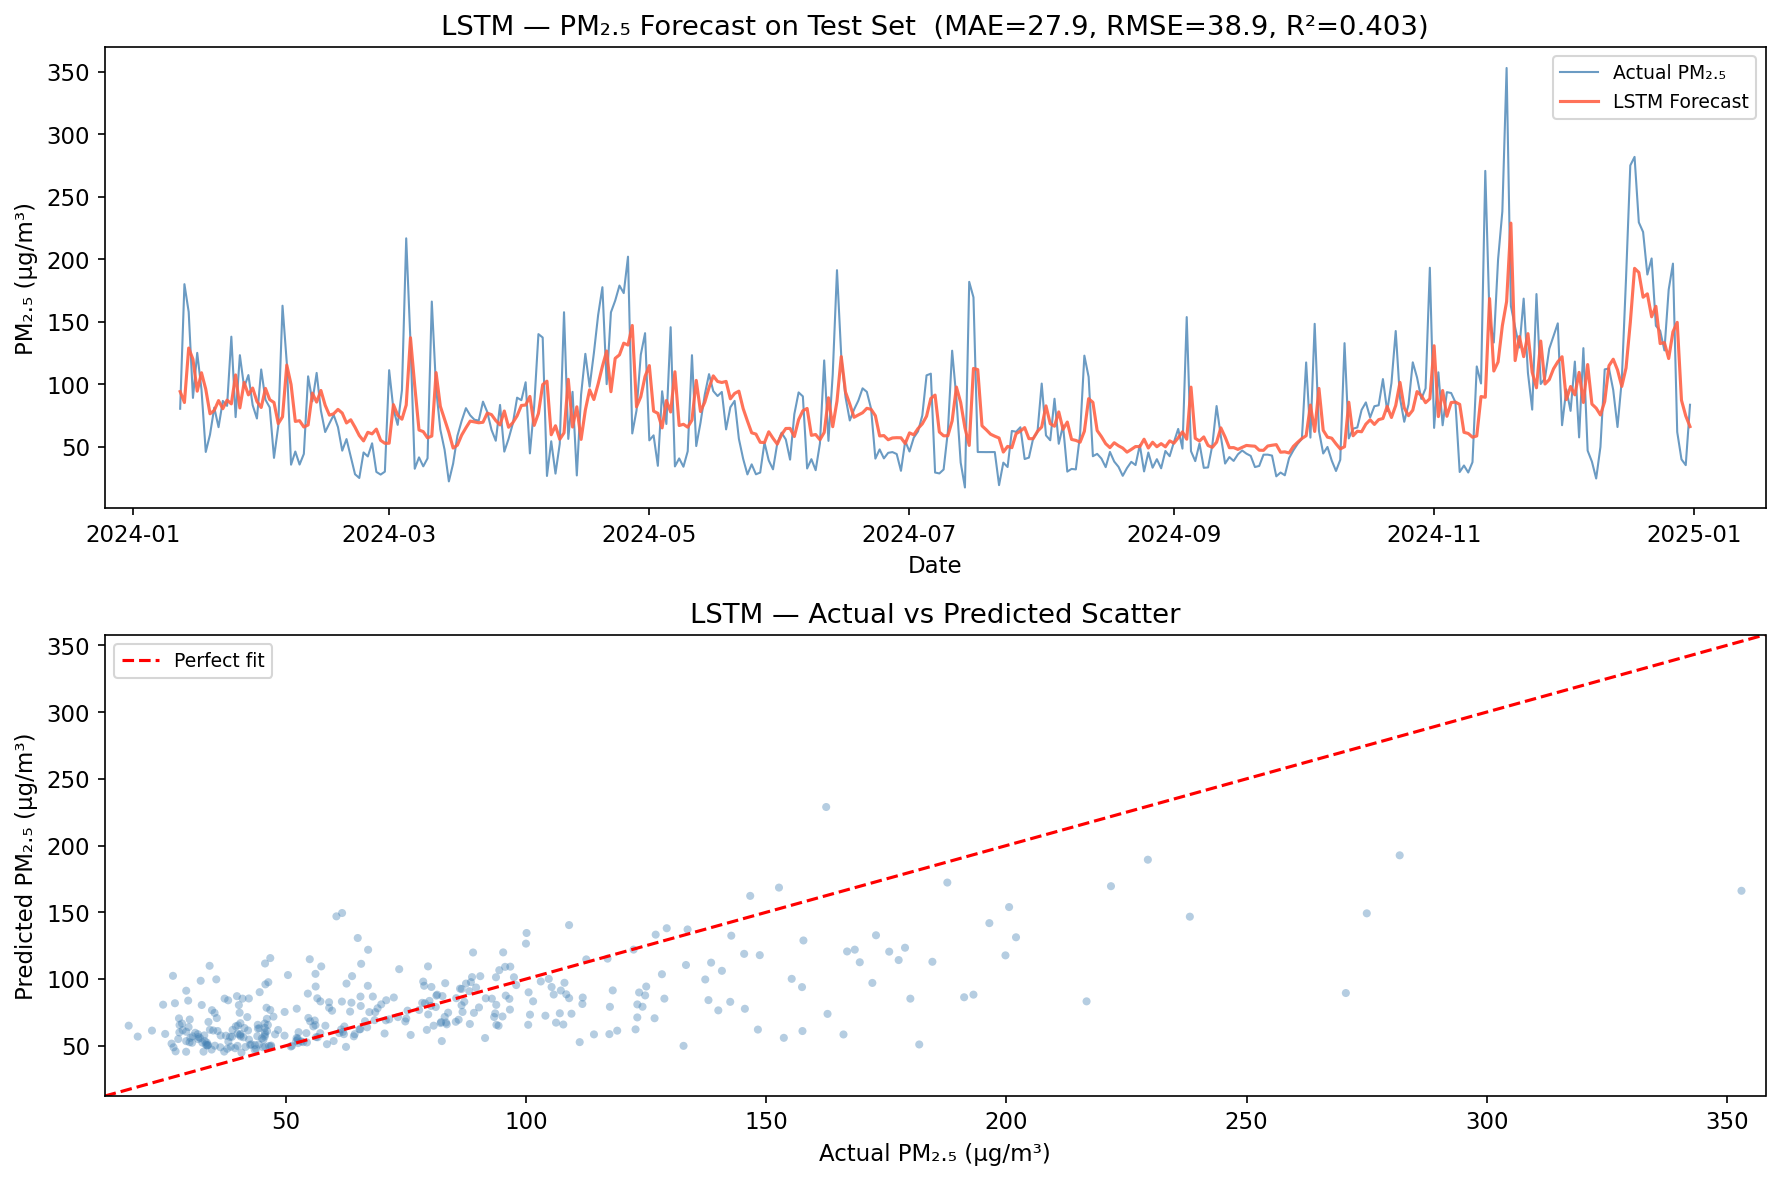

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Full test period
ax = axes[0]
plot_dates = dates_test[:len(y_true)] if len(dates_test) >= len(y_true) else np.arange(len(y_true))
ax.plot(plot_dates, y_true, color="steelblue", lw=1,   label="Actual PM₂.₅",    alpha=0.8)
ax.plot(plot_dates, y_pred, color="tomato",    lw=1.5, label="LSTM Forecast",    alpha=0.9)
ax.set_xlabel("Date")
ax.set_ylabel("PM₂.₅ (µg/m³)")
ax.set_title(f"LSTM — PM₂.₅ Forecast on Test Set  (MAE={mae:.1f}, RMSE={rmse:.1f}, R²={r2:.3f})")
ax.legend(fontsize=9)

# Scatter: actual vs predicted
ax = axes[1]
ax.scatter(y_true, y_pred, alpha=0.4, s=15, color="steelblue", edgecolors="none")
lim = [min(y_true.min(), y_pred.min())-5, max(y_true.max(), y_pred.max())+5]
ax.plot(lim, lim, "r--", lw=1.5, label="Perfect fit")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Actual PM₂.₅ (µg/m³)")
ax.set_ylabel("Predicted PM₂.₅ (µg/m³)")
ax.set_title("LSTM — Actual vs Predicted Scatter")
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(OUT, "lstm_forecast.png"))
plt.show()